In [9]:
!pip install torchsummary

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import OneCycleLR
from torchsummary import summary

from pathlib import Path
from tqdm import tqdm
import random
import copy
import shutil
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from PIL import Image


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset

In [ ]:
# Define your desired class mapping
desired_class_mapping = {
    'Fresh': 0,
    'Stage1': 1,
    'Stage-2': 2,
    'Stage-3': 3
}

# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load data from the split directories using ImageFolder with transformations
train_dataset = datasets.ImageFolder('/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/train', transform=transform)
val_dataset = datasets.ImageFolder('/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/val', transform=transform)
test_dataset = datasets.ImageFolder('/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/test', transform=transform)

print(f"Original class mapping: {train_dataset.class_to_idx}")

# Update the samples with new mapping based on folder names
train_dataset.samples = [(path, desired_class_mapping[Path(path).parent.name])
                          for path, _ in train_dataset.samples]
val_dataset.samples = [(path, desired_class_mapping[Path(path).parent.name])
                        for path, _ in val_dataset.samples]
test_dataset.samples = [(path, desired_class_mapping[Path(path).parent.name])
                         for path, _ in test_dataset.samples]

# Update targets
train_dataset.targets = [s[1] for s in train_dataset.samples]
val_dataset.targets = [s[1] for s in val_dataset.samples]
test_dataset.targets = [s[1] for s in test_dataset.samples]

# Override the class_to_idx with your desired mapping
train_dataset.class_to_idx = desired_class_mapping
val_dataset.class_to_idx = desired_class_mapping
test_dataset.class_to_idx = desired_class_mapping

# Update the classes list
train_dataset.classes = list(desired_class_mapping.keys())
val_dataset.classes = list(desired_class_mapping.keys())
test_dataset.classes = list(desired_class_mapping.keys())

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,
                         num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False,
                       num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False,
                        num_workers=4, pin_memory=True)

print(f"Final counts - Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
print(f"New class mapping: {train_dataset.class_to_idx}")
print(f"Classes: {train_dataset.classes}")

Original class mapping: {'Fresh': 0, 'Stage-2': 1, 'Stage-3': 2, 'Stage1': 3}
Final counts - Train: 3203 | Val: 400 | Test: 401
New class mapping: {'Fresh': 0, 'Stage1': 1, 'Stage-2': 2, 'Stage-3': 3}
Classes: ['Fresh', 'Stage1', 'Stage-2', 'Stage-3']


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


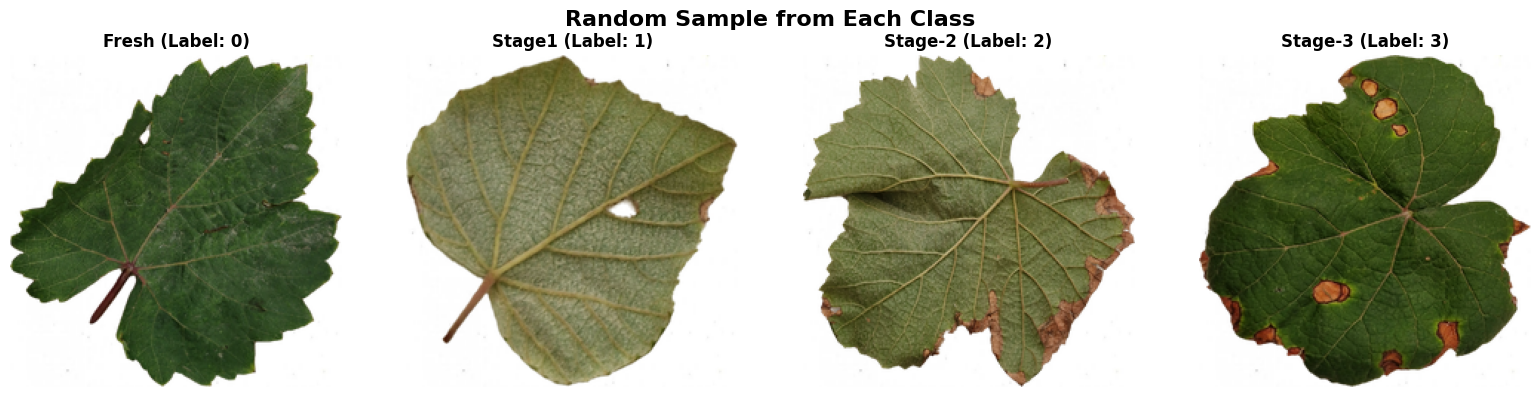

Class Distribution in Training Set:
Fresh: 800 images
Stage1: 800 images
Stage-2: 800 images
Stage-3: 803 images


In [28]:
# Set up the plot
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Random Sample from Each Class', fontsize=16, fontweight='bold')

# Get class names in order
class_names = list(desired_class_mapping.keys())

# For each class, find a random sample and display it
for idx, class_name in enumerate(class_names):
    # Find all samples belonging to this class
    class_samples = [(path, label) for path, label in train_dataset.samples
                     if label == desired_class_mapping[class_name]]

    # Pick a random sample
    random_sample_path, label = random.choice(class_samples)

    # Load and display the image
    from PIL import Image
    img = Image.open(random_sample_path)

    axes[idx].imshow(img)
    axes[idx].set_title(f'{class_name} (Label: {label})', fontsize=12, fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("Class Distribution in Training Set:")
for class_name in class_names:
    count = sum(1 for _, label in train_dataset.samples
                if label == desired_class_mapping[class_name])
    print(f"{class_name}: {count} images")

## Model

In [ ]:
class GrapevineNet_Lite(nn.Module):
    """
    Lightweight Transfer Learning Model
    Optimized for small datasets (~4k images)
    """

    def __init__(self, num_classes=4, dropout=0.3):
        super().__init__()

        # Pretrained EfficientNet-B0
        self.backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")

        # Freeze most of the backbone
        for i, block in enumerate(self.backbone.features):
            if i < 6:  # freeze ~75%
                for param in block.parameters():
                    param.requires_grad = False

        # Lightweight SE attention (final features only)
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(1280, 1280 // 16, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(1280 // 16, 1280, 1),
            nn.Sigmoid()
        )

        # Classification head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(1280, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.backbone.features(x)
        x = self.se(x) * x
        x = self.classifier(x)
        return x


device = "cuda" if torch.cuda.is_available() else "cpu"
model = GrapevineNet_Lite(num_classes=4, dropout=0.3).to(device)
summary(model, input_size=(3, 224, 224), device=device)


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

## Training

In [32]:
def compute_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return acc, prec, rec, f1

output_dir = Path("/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output")
output_dir.mkdir(parents=True, exist_ok=True)

# Optimizer + Loss
learning_rate = 1e-3
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Scheduler
num_epochs = 20
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=learning_rate,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.4,   # slower warm-up
    anneal_strategy='cos'
)

# Mixed precision
scaler = torch.amp.GradScaler()

# Early stopping
patience = 5
best_val_acc = 0.0
patience_counter = 0

# Metric storage
train_losses, val_losses = [], []
train_accs, val_accs = [], []
train_precs, val_precs = [], []
train_recs, val_recs = [], []
train_f1s, val_f1s = [], []

for epoch in range(num_epochs):
    # training
    model.train()
    train_true, train_pred = [], []
    train_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    for images, labels in pbar:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_loss += loss.item() * images.size(0)
        train_true.extend(labels.cpu().numpy())
        train_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    train_loss /= len(train_loader.dataset)
    train_acc, train_prec, train_rec, train_f1 = compute_metrics(train_true, train_pred)

    # validation
    model.eval()
    val_true, val_pred = [], []
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]  "):
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type=device):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_true.extend(labels.cpu().numpy())
            val_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())

    val_loss /= len(val_loader.dataset)
    val_acc, val_prec, val_rec, val_f1 = compute_metrics(val_true, val_pred)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_precs.append(train_prec)
    val_precs.append(val_prec)
    train_recs.append(train_rec)
    val_recs.append(val_rec)
    train_f1s.append(train_f1)
    val_f1s.append(val_f1)

    # Print metrics
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train - Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Prec: {train_prec:.4f} | Rec: {train_rec:.4f} | F1: {train_f1:.4f}")
    print(f"Val   - Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | F1: {val_f1:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
        }, output_dir / 'best_model.pth')
        print(f"New best model saved! Val Acc: {val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

# save history
history_df = pd.DataFrame({
    'epoch': range(1, len(train_losses) + 1),
    'train_loss': train_losses,
    'train_accuracy': train_accs,
    'train_precision': train_precs,
    'train_recall': train_recs,
    'train_f1': train_f1s,
    'val_loss': val_losses,
    'val_accuracy': val_accs,
    'val_precision': val_precs,
    'val_recall': val_recs,
    'val_f1': val_f1s
})
history_csv_path = output_dir / 'training_history.csv'
history_df.to_csv(history_csv_path, index=False)
print(f"Training history saved to: {history_csv_path}")

# load best saved model
checkpoint = torch.load(output_dir / 'best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

test_true, test_pred = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        with torch.amp.autocast(device_type=device):
            outputs = model(images)

        test_true.extend(labels.cpu().numpy())
        test_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())

test_acc, test_prec, test_rec, test_f1 = compute_metrics(test_true, test_pred)

# Save test results
test_results_df = pd.DataFrame({
    'metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'value': [test_acc, test_prec, test_rec, test_f1]
})
test_csv_path = output_dir / 'test_results.csv'
test_results_df.to_csv(test_csv_path, index=False)
print(f"Test results saved to: {test_csv_path}")

# Comprehensive summary
summary_df = pd.DataFrame({
    'Dataset': ['Train (Final)', 'Validation (Best)', 'Test'],
    'Accuracy': [train_accs[-1], best_val_acc, test_acc],
    'Precision': [train_precs[-1], val_precs[val_accs.index(best_val_acc)], test_prec],
    'Recall': [train_recs[-1], val_recs[val_accs.index(best_val_acc)], test_rec],
    'F1 Score': [train_f1s[-1], val_f1s[val_accs.index(best_val_acc)], test_f1]
})
summary_csv_path = output_dir / 'model_summary.csv'
summary_df.to_csv(summary_csv_path, index=False)
print(f"Model summary saved to: {summary_csv_path}")

Epoch 1/20 [Val]  :   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 1/20 [Val]  : 100%|██████████| 13/13 [00:02<00:00,  6.22it/s]


Epoch 1/20
Train - Loss: 1.2508 | Acc: 0.5370 | Prec: 0.5461 | Rec: 0.5369 | F1: 0.5273
Val   - Loss: 0.9560 | Acc: 0.6450 | Prec: 0.6607 | Rec: 0.6450 | F1: 0.6070
New best model saved! Val Acc: 0.6450


Epoch 2/20 [Train]:   0%|          | 0/101 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 2/20 [Val]  :   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if n

Epoch 2/20
Train - Loss: 0.8087 | Acc: 0.7509 | Prec: 0.7469 | Rec: 0.7507 | F1: 0.7463
Val   - Loss: 0.6703 | Acc: 0.8175 | Prec: 0.8161 | Rec: 0.8175 | F1: 0.8127
New best model saved! Val Acc: 0.8175


Epoch 3/20 [Train]:   0%|          | 0/101 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 3/20 [Val]  :   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if n

...

Epoch 12/20
Train - Loss: 0.4111 | Acc: 0.9744 | Prec: 0.9744 | Rec: 0.9744 | F1: 0.9744
Val   - Loss: 0.6132 | Acc: 0.8625 | Prec: 0.8638 | Rec: 0.8625 | F1: 0.8606


Epoch 13/20 [Train]:   0%|          | 0/101 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Epoch 13/20 [Val]  :   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if

Epoch 13/20
Train - Loss: 0.3908 | Acc: 0.9825 | Prec: 0.9825 | Rec: 0.9825 | F1: 0.9825
Val   - Loss: 0.5952 | Acc: 0.8825 | Prec: 0.8852 | Rec: 0.8825 | F1: 0.8814
Early stopping triggered after 13 epochs
Training history saved to: /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output/training_history.csv


Testing:   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Testing: 100%|██████████| 13/13 [00:43<00:00,  3.33s/it]

Test results saved to: /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output/test_results.csv
Model summary saved to: /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output/model_summary.csv


In [ ]:
# Final metrics for training (last epoch)
final_train_metrics = {
    'Accuracy': train_accs[-1],
    'Precision': train_precs[-1],
    'Recall': train_recs[-1],
    'F1 Score': train_f1s[-1]
}

# Best validation metrics
best_val_idx = val_accs.index(best_val_acc)
best_val_metrics = {
    'Accuracy': val_accs[best_val_idx],
    'Precision': val_precs[best_val_idx],
    'Recall': val_recs[best_val_idx],
    'F1 Score': val_f1s[best_val_idx]
}

# Test metrics
test_metrics = {
    'Accuracy': test_acc,
    'Precision': test_prec,
    'Recall': test_rec,
    'F1 Score': test_f1
}

# Print final metrics
print("\nFinal Model Metrics:\n")
print("Training (Last Epoch):")
for k, v in final_train_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nValidation (Best Epoch):")
for k, v in best_val_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nTest Set:")
for k, v in test_metrics.items():
    print(f"  {k}: {v:.4f}")

# Optional: save to CSV
summary_df = pd.DataFrame({
    'Dataset': ['Train (Final)', 'Validation (Best)', 'Test'],
    'Accuracy': [final_train_metrics['Accuracy'], best_val_metrics['Accuracy'], test_metrics['Accuracy']],
    'Precision': [final_train_metrics['Precision'], best_val_metrics['Precision'], test_metrics['Precision']],
    'Recall': [final_train_metrics['Recall'], best_val_metrics['Recall'], test_metrics['Recall']],
    'F1 Score': [final_train_metrics['F1 Score'], best_val_metrics['F1 Score'], test_metrics['F1 Score']]
})

summary_csv_path = output_dir / 'model_summary.csv'
summary_df.to_csv(summary_csv_path, index=False)
print(f"Model summary saved to: {summary_csv_path}")


Final Model Metrics:

Training (Last Epoch):
  Accuracy: 0.9825
  Precision: 0.9825
  Recall: 0.9825
  F1 Score: 0.9825

Validation (Best Epoch):
  Accuracy: 0.9000
  Precision: 0.9041
  Recall: 0.9000
  F1 Score: 0.9004

Test Set:
  Accuracy: 0.8653
  Precision: 0.8667
  Recall: 0.8653
  F1 Score: 0.8653

Model summary saved to: /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output/model_summary.csv


In [ ]:
# Set theme
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)

# Load training history
output_dir = Path("/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output")
history_path = output_dir / 'training_history.csv'
history_df = pd.read_csv(history_path)

# Colors for metrics
colors = {
    'loss': ('#1f77b4', '#ff7f0e'),
    'accuracy': ('#2ca02c', '#d62728'),
    'precision': ('#9467bd', '#8c564b'),
    'recall': ('#e377c2', '#7f7f7f'),
    'f1': ('#17becf', '#bcbd22')
}

# Function to create and save a single metric plot
def save_metric_plot(train_col, val_col, title, ylabel, train_color, val_color, filename):
    plt.figure(figsize=(8, 6))
    plt.plot(history_df['epoch'], history_df[train_col], label='Train', color=train_color,
             linewidth=2, marker='o', markersize=4, alpha=0.8)
    plt.plot(history_df['epoch'], history_df[val_col], label='Validation', color=val_color,
             linewidth=2, linestyle='--', marker='s', markersize=4, alpha=0.8)
    plt.fill_between(history_df['epoch'], history_df[train_col], history_df[val_col],
                     color='gray', alpha=0.1)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(frameon=False, fontsize=10)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=300)
    plt.close()
    print(f"{title} saved as {filename}")

# Generate separate plots
save_metric_plot('train_loss', 'val_loss', 'Loss over Epochs', 'Loss', *colors['loss'], 'loss_plot.png')
save_metric_plot('train_accuracy', 'val_accuracy', 'Accuracy over Epochs', 'Accuracy', *colors['accuracy'], 'accuracy_plot.png')
save_metric_plot('train_precision', 'val_precision', 'Precision over Epochs', 'Precision', *colors['precision'], 'precision_plot.png')
save_metric_plot('train_recall', 'val_recall', 'Recall over Epochs', 'Recall', *colors['recall'], 'recall_plot.png')
save_metric_plot('train_f1', 'val_f1', 'F1 Score over Epochs', 'F1 Score', *colors['f1'], 'f1_plot.png')

# Combined metrics plot (train vs validation)
plt.figure(figsize=(8, 6))
metrics = ['accuracy', 'precision', 'recall', 'f1']
combined_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, metric in enumerate(metrics):
    plt.plot(history_df['epoch'], history_df[f'val_{metric}'], color=combined_colors[i],
             linewidth=2, label=f'Val {metric.capitalize()}', marker='o')
    plt.plot(history_df['epoch'], history_df[f'train_{metric}'], color=combined_colors[i],
             linewidth=1, linestyle='--', alpha=0.6, label=f'Train {metric.capitalize()}')

plt.title('All Metrics Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig(output_dir / 'all_metrics_plot.png', dpi=300)
plt.close()
print("All metrics comparison plot saved as all_metrics_plot.png")


Loss over Epochs saved as loss_plot.png
Accuracy over Epochs saved as accuracy_plot.png
Precision over Epochs saved as precision_plot.png
Recall over Epochs saved as recall_plot.png
F1 Score over Epochs saved as f1_plot.png
All metrics comparison plot saved as all_metrics_plot.png


## Testing

In [ ]:
# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Load the best saved model
output_dir = Path("/content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output")
checkpoint_path = output_dir / 'best_model.pth'

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"Best model loaded from epoch {checkpoint['epoch'] + 1} with validation accuracy: {checkpoint['val_acc']:.4f}")

# Lists to store results
image_paths_list = []
true_labels_list = []
predicted_labels_list = []
true_classes_list = []
predicted_classes_list = []
confidence_scores_list = []

# Get class names
class_names = test_dataset.classes

# Make predictions on test data
with torch.no_grad():  # Disable gradient computation for inference
    for batch_idx, (images, labels) in enumerate(tqdm(test_loader, desc="Making predictions")):
        # Move data to device
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)

        # Get predictions and confidence scores
        probabilities = torch.softmax(outputs, dim=1)
        confidence_scores, predictions = torch.max(probabilities, dim=1)

        # Get image paths for this batch
        start_idx = batch_idx * test_loader.batch_size
        end_idx = min(start_idx + len(labels), len(test_dataset.samples))

        for i in range(len(labels)):
            # Get the actual index in the dataset
            idx = start_idx + i

            # Get image path
            image_path = test_dataset.samples[idx][0]

            # Get true and predicted labels
            true_label = labels[i].item()
            predicted_label = predictions[i].item()

            # Get class names
            true_class = class_names[true_label]
            predicted_class = class_names[predicted_label]

            # Get confidence score
            confidence = confidence_scores[i].item()

            # Append to lists
            image_paths_list.append(image_path)
            true_labels_list.append(true_label)
            predicted_labels_list.append(predicted_label)
            true_classes_list.append(true_class)
            predicted_classes_list.append(predicted_class)
            confidence_scores_list.append(confidence)

print(f"Total predictions made: {len(image_paths_list)}")

# Create DataFrame from lists
results_df = pd.DataFrame({
    'image_path': image_paths_list,
    'true_label': true_labels_list,
    'predicted_label': predicted_labels_list,
    'true_class': true_classes_list,
    'predicted_class': predicted_classes_list,
    'confidence': confidence_scores_list
})

# Save results to CSV
results_csv_path = output_dir / 'test_predictions.csv'
results_df.to_csv(results_csv_path, index=False)
print(f"Predictions saved to: {results_csv_path}")
print(f"Total records: {len(results_df)}")

# Show sample of predictions
print("results:")
print(results_df.head(10).to_string())

# Calculate and display basic statistics
correct_predictions = (results_df['true_label'] == results_df['predicted_label']).sum()
total_predictions = len(results_df)
test_accuracy = correct_predictions / total_predictions


print(f"Total test samples: {total_predictions}")
print(f"Correct predictions: {correct_predictions}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Incorrect predictions: {total_predictions - correct_predictions}")

# Save accuracy to a simple text file
accuracy_file = output_dir / 'test_accuracy.txt'
with open(accuracy_file, 'w') as f:
    f.write(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)\n")
    f.write(f"Correct/Total: {correct_predictions}/{total_predictions}\n")
print(f"Accuracy saved to: {accuracy_file}")

Using device: cuda
Best model loaded from epoch 8 with validation accuracy: 0.9000


Making predictions:   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Making predictions: 100%|██████████| 13/13 [00:03<00:00,  4.23it/s]


Total predictions made: 401
Predictions saved to: /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/output/test_predictions.csv
Total records: 401
results:
                                                                      image_path  true_label  predicted_label true_class predicted_class  confidence
0  /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/test/Fresh/Fresh_125.png           0                1      Fresh          Stage1    0.773096
1  /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/test/Fresh/Fresh_133.png           0                0      Fresh           Fresh    0.929169
2  /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/test/Fresh/Fresh_138.png           0                0      Fresh           Fresh    0.601610
3  /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/test/Fresh/Fresh_147.png           0                0      Fresh           Fresh    0.961011
4  /content/drive/MyDrive/TermPaper/GrapeVineDataSplits/test/Fresh/Fresh_148.png           0    

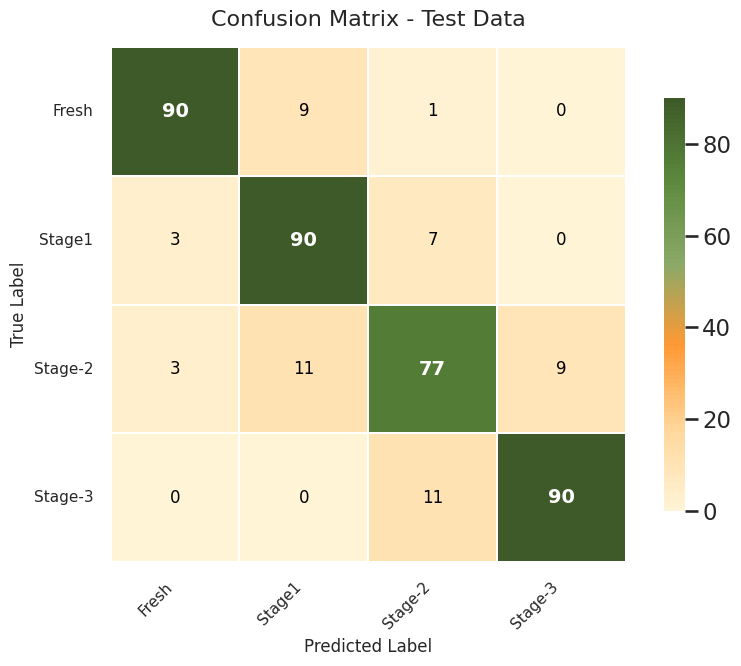

In [ ]:
# Clean professional style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Class names
classes = ['Fresh', 'Stage1', 'Stage-2', 'Stage-3']

# Compute confusion matrix
cm = confusion_matrix(test_true, test_pred)

# Create custom colormap with yellow and green tones (darker)
colors = ['#FFF4D6', '#FFD699', '#FF9933', '#8BA968', '#5C8A3D', '#3D5A28']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('custom_yellow_green', colors, N=n_bins)

# Create figure
plt.figure(figsize=(9, 7), facecolor='white')
ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=cmap,
    cbar=True,
    xticklabels=classes,
    yticklabels=classes,
    linewidths=1.2,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8}
)

# Style the text annotations
for i, text in enumerate(ax.texts):
    row = i // cm.shape[1]
    col = i % cm.shape[1]
    if row == col:  # diagonal
        text.set_color('white')
        text.set_fontweight('bold')
        text.set_fontsize(14)
    else:  # off-diagonal
        text.set_color('black')
        text.set_fontweight('normal')
        text.set_fontsize(12)

# Title and labels
plt.title('Confusion Matrix - Test Data', fontsize=16, fontweight='normal', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='normal')
plt.ylabel('True Label', fontsize=12, fontweight='normal')

# Tick styling
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

# Adjust layout
plt.tight_layout()

# Save figure
plt.savefig(output_dir / "confusion_matrix_test.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

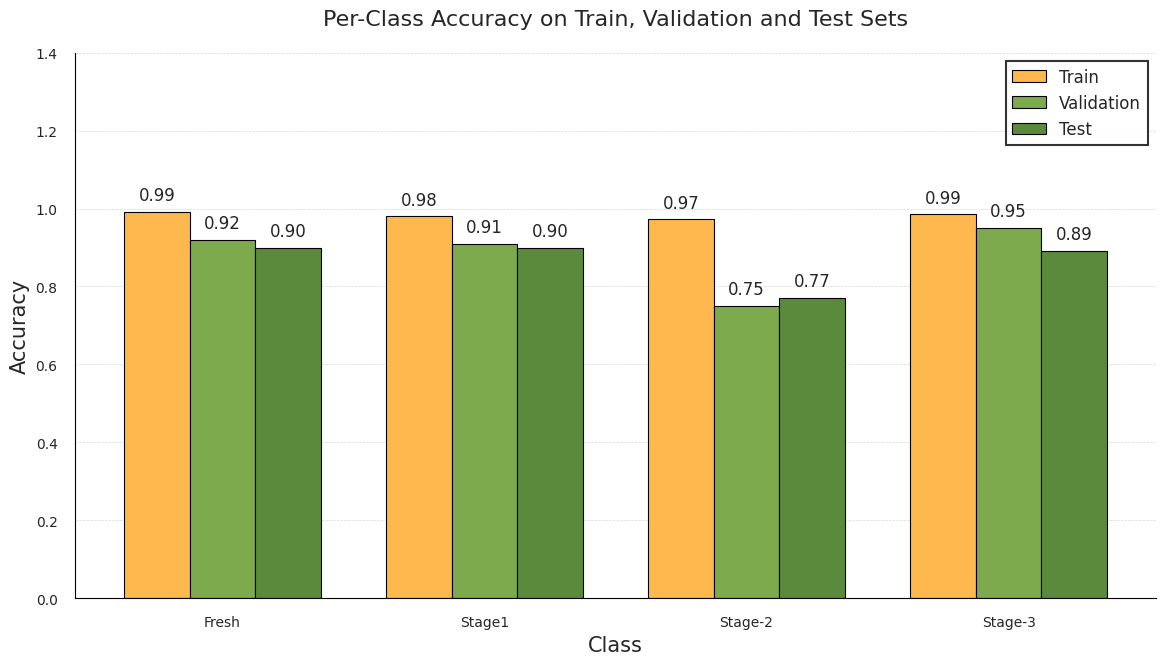

In [ ]:
# Clean professional style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Class names
classes = ['Fresh', 'Stage1', 'Stage-2', 'Stage-3']

# Compute confusion matrices
cm_train = confusion_matrix(train_true, train_pred)
cm_val = confusion_matrix(val_true, val_pred)
cm_test = confusion_matrix(test_true, test_pred)

# Per-class accuracy for each set
train_acc = cm_train.diagonal() / cm_train.sum(axis=1)
val_acc = cm_val.diagonal() / cm_val.sum(axis=1)
test_acc = cm_test.diagonal() / cm_test.sum(axis=1)

# Create figure
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

# Bar positioning
x = np.arange(len(classes))
width = 0.25

# Create bars with colors from reference image
bars1 = ax.bar(x - width, train_acc, width, label='Train',
               color='#FFB84D', edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x, val_acc, width, label='Validation',
               color='#7CAA4D', edgecolor='black', linewidth=0.8)
bars3 = ax.bar(x + width, test_acc, width, label='Test',
               color='#5C8A3D', edgecolor='black', linewidth=0.8)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=12, fontweight='normal')

# Title and labels
ax.set_title('Per-Class Accuracy on Train, Validation and Test Sets',
             fontsize=16, fontweight='normal', pad=20)
ax.set_ylabel('Accuracy', fontsize=15, fontweight='normal')
ax.set_xlabel('Class', fontsize=15, fontweight='normal')

# X-axis
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=11)

# Y-axis
ax.set_ylim(0, 1.2)
ax.set_yticks(np.arange(0, 1.5, 0.2))
ax.tick_params(axis='both', labelsize=10)

# Grid
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray', linewidth=0.5)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('black')
    ax.spines[spine].set_linewidth(0.8)

# Legend
ax.legend(loc='upper right', frameon=True, fontsize=12,
          edgecolor='black', fancybox=False)

# Tight layout
plt.tight_layout()

# Save figure
plt.savefig(output_dir / 'per_class_accuracy_all_sets.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

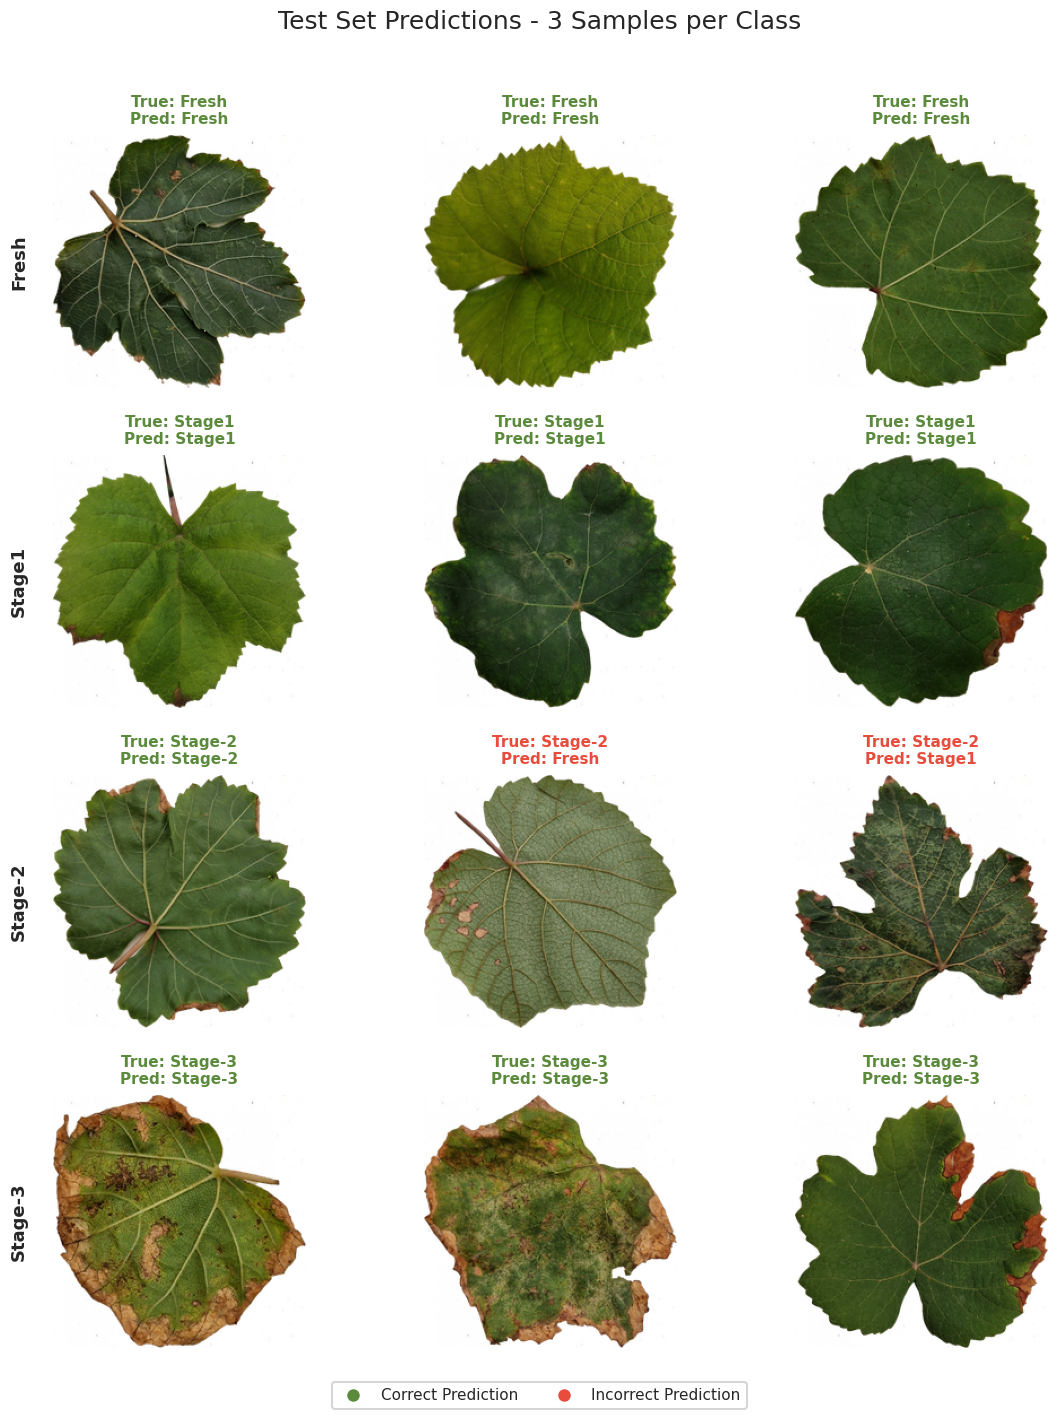

In [ ]:
# Clean professional style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Class names and mapping
classes = ['Fresh', 'Stage1', 'Stage-2', 'Stage-3']
class_mapping = {'Fresh': 0, 'Stage1': 1, 'Stage-2': 2, 'Stage-3': 3}

# Set up the plot - 4 rows (classes) x 3 columns (samples)
fig, axes = plt.subplots(4, 3, figsize=(12, 14), facecolor='white')
fig.suptitle('Test Set Predictions - 3 Samples per Class',
             fontsize=18, fontweight='normal', y=0.995)

# For each class
for row_idx, class_name in enumerate(classes):
    # Find all samples belonging to this class in test set
    class_samples = [(path, label) for path, label in test_dataset.samples
                     if label == class_mapping[class_name]]

    # Pick 3 random samples
    selected_samples = random.sample(class_samples, min(3, len(class_samples)))

    for col_idx, (sample_path, true_label) in enumerate(selected_samples):
        ax = axes[row_idx, col_idx]

        # Load the image
        img = Image.open(sample_path)
        ax.imshow(img)

        # Find the prediction for this sample
        # Get the index of this sample in test_dataset
        sample_idx = test_dataset.samples.index((sample_path, true_label))
        pred_label = test_pred[sample_idx]

        # Determine if prediction is correct
        is_correct = true_label == pred_label
        title_color = '#5C8A3D' if is_correct else '#E74C3C'

        # Get class names for labels
        true_class = classes[true_label]
        pred_class = classes[pred_label]

        # Add title with true and predicted labels
        title = f'True: {true_class}\nPred: {pred_class}'
        ax.set_title(title, fontsize=11, fontweight='bold',
                    color=title_color, pad=8)

        # Remove axis
        ax.axis('off')

        # Add class label on the left for first column
        if col_idx == 0:
            ax.text(-0.1, 0.5, class_name, transform=ax.transAxes,
                   fontsize=13, fontweight='bold', rotation=90,
                   va='center', ha='right')

# Add legend
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#5C8A3D',
               markersize=10, label='Correct Prediction'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#E74C3C',
               markersize=10, label='Incorrect Prediction')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
          fontsize=11, frameon=True, bbox_to_anchor=(0.5, -0.01))

# Adjust layout
plt.tight_layout(rect=[0, 0.02, 1, 0.99])

# Save figure
plt.savefig(output_dir / 'test_samples_visualization.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

## Pretrained Models

Using device: cuda

EfficientNetB2 - Epoch 1/13
------------------------------------------------------------


Validation: 100%|██████████| 13/13 [00:02<00:00,  4.39it/s]


Train Loss: 1.0362 Acc: 0.5308
Val Loss: 0.7540 Acc: 0.6475
Best model saved with accuracy: 0.6475

EfficientNetB2 - Epoch 2/13
------------------------------------------------------------


Validation: 100%|██████████| 13/13 [00:02<00:00,  5.38it/s]


Train Loss: 0.8132 Acc: 0.6469
Val Loss: 0.7760 Acc: 0.6625
Best model saved with accuracy: 0.6625

EfficientNetB2 - Epoch 3/13
------------------------------------------------------------


...

Train Loss: 0.6498 Acc: 0.7100
Val Loss: 0.5891 Acc: 0.7325

EfficientNet-B2 Results:


Testing: 100%|██████████| 13/13 [00:02<00:00,  5.44it/s]


Test Accuracy: 0.7905
Precision: 0.7896
Recall: 0.7905
F1-Score: 0.7884

Classification Report:
              precision    recall  f1-score   support

       Fresh       0.81      0.87      0.84       100
      Stage1       0.72      0.78      0.75       100
     Stage-2       0.74      0.63      0.68       100
     Stage-3       0.88      0.88      0.88       101

    accuracy                           0.79       401
   macro avg       0.79      0.79      0.79       401
weighted avg       0.79      0.79      0.79       401


ResNet50 Results:


Testing:   0%|          | 0/13 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
Testing: 100%|██████████| 13/13 [00:02<00:00,  5.16it/s]


Test Accuracy: 0.7207
Precision: 0.7377
Recall: 0.7207
F1-Score: 0.7262

Classification Report:
              precision    recall  f1-score   support

       Fresh       0.85      0.79      0.82       100
      Stage1       0.57      0.69      0.63       100
     Stage-2       0.62      0.63      0.62       100
     Stage-3       0.91      0.77      0.83       101

    accuracy                           0.72       401
   macro avg       0.74      0.72      0.73       401
weighted avg       0.74      0.72      0.73       401



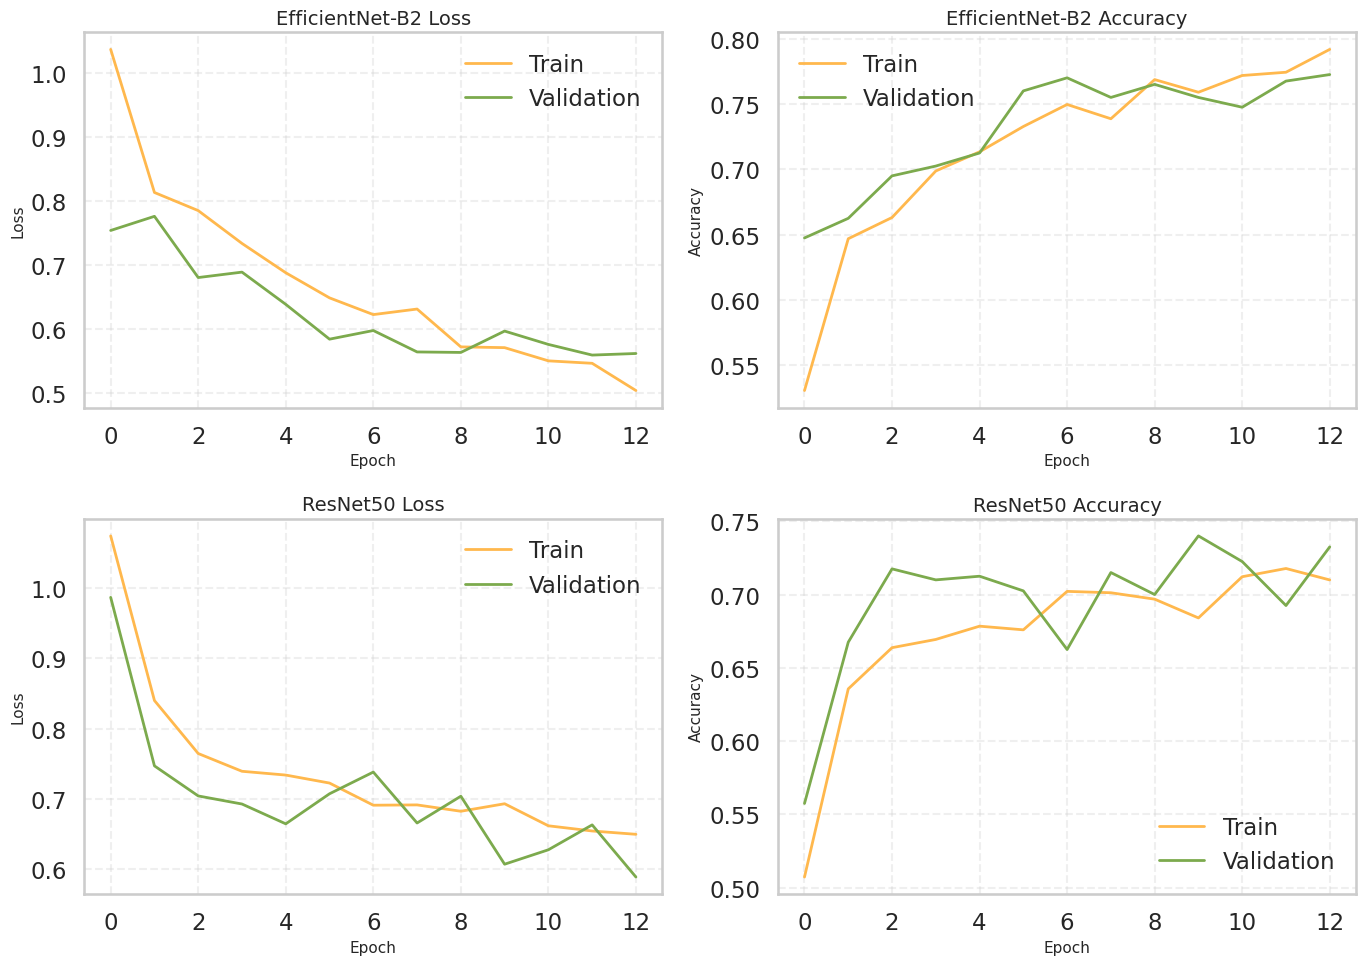

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

NUM_CLASSES = 4
EPOCHS = 13
LEARNING_RATE = 0.001
classes = ['Fresh', 'Stage1', 'Stage-2', 'Stage-3']

def build_efficientnet_b2(num_classes=NUM_CLASSES):
    model = models.efficientnet_b2(pretrained=True)

    for param in model.parameters():
        param.requires_grad = False

    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, 256),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, num_classes)
    )

    return model.to(device)

def build_resnet50(num_classes=NUM_CLASSES):
    model = models.resnet50(pretrained=True)

    for param in model.parameters():
        param.requires_grad = False

    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_ftrs, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes)
    )

    return model.to(device)

def train_model(model, train_loader, val_loader, model_name, num_epochs=EPOCHS):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                      factor=0.5, patience=5)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f'\n{model_name} - Epoch {epoch+1}/{num_epochs}')
        print('-' * 60)

        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader, desc='Training'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = running_corrects.double() / len(train_loader.dataset)

        model.eval()
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc='Validation'):
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_acc = running_corrects.double() / len(val_loader.dataset)

        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc.cpu().numpy())
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc.cpu().numpy())

        print(f'Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f}')
        print(f'Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}')

        scheduler.step(epoch_val_loss)

        if epoch_val_acc > best_acc:
            best_acc = epoch_val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), f'{model_name}_best_model.pth')
            print(f'Best model saved with accuracy: {best_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Testing'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

efficientnet_model = build_efficientnet_b2()
efficientnet_model, efficientnet_history = train_model(
    efficientnet_model, train_loader, val_loader, 'EfficientNetB2'
)

resnet_model = build_resnet50()
resnet_model, resnet_history = train_model(
    resnet_model, train_loader, val_loader, 'ResNet50'
)

print("\nEfficientNet-B2 Results:")
efficientnet_true, efficientnet_pred = evaluate_model(efficientnet_model, test_loader)
efficientnet_acc = np.mean(efficientnet_true == efficientnet_pred)
efficientnet_precision = precision_score(efficientnet_true, efficientnet_pred, average='weighted')
efficientnet_recall = recall_score(efficientnet_true, efficientnet_pred, average='weighted')
efficientnet_f1 = f1_score(efficientnet_true, efficientnet_pred, average='weighted')

print(f"Test Accuracy: {efficientnet_acc:.4f}")
print(f"Precision: {efficientnet_precision:.4f}")
print(f"Recall: {efficientnet_recall:.4f}")
print(f"F1-Score: {efficientnet_f1:.4f}")
print("\nClassification Report:")
print(classification_report(efficientnet_true, efficientnet_pred, target_names=classes))

print("\nResNet50 Results:")
resnet_true, resnet_pred = evaluate_model(resnet_model, test_loader)
resnet_acc = np.mean(resnet_true == resnet_pred)
resnet_precision = precision_score(resnet_true, resnet_pred, average='weighted')
resnet_recall = recall_score(resnet_true, resnet_pred, average='weighted')
resnet_f1 = f1_score(resnet_true, resnet_pred, average='weighted')

print(f"Test Accuracy: {resnet_acc:.4f}")
print(f"Precision: {resnet_precision:.4f}")
print(f"Recall: {resnet_recall:.4f}")
print(f"F1-Score: {resnet_f1:.4f}")
print("\nClassification Report:")
print(classification_report(resnet_true, resnet_pred, target_names=classes))

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')

axes[0, 0].plot(efficientnet_history['train_loss'], label='Train', color='#FFB84D', linewidth=2)
axes[0, 0].plot(efficientnet_history['val_loss'], label='Validation', color='#7CAA4D', linewidth=2)
axes[0, 0].set_title('EfficientNet-B2 Loss', fontsize=14, fontweight='normal')
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.3)

axes[0, 1].plot(efficientnet_history['train_acc'], label='Train', color='#FFB84D', linewidth=2)
axes[0, 1].plot(efficientnet_history['val_acc'], label='Validation', color='#7CAA4D', linewidth=2)
axes[0, 1].set_title('EfficientNet-B2 Accuracy', fontsize=14, fontweight='normal')
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Accuracy', fontsize=11)
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.3)

axes[1, 0].plot(resnet_history['train_loss'], label='Train', color='#FFB84D', linewidth=2)
axes[1, 0].plot(resnet_history['val_loss'], label='Validation', color='#7CAA4D', linewidth=2)
axes[1, 0].set_title('ResNet50 Loss', fontsize=14, fontweight='normal')
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Loss', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(True, linestyle='--', alpha=0.3)

axes[1, 1].plot(resnet_history['train_acc'], label='Train', color='#FFB84D', linewidth=2)
axes[1, 1].plot(resnet_history['val_acc'], label='Validation', color='#7CAA4D', linewidth=2)
axes[1, 1].set_title('ResNet50 Accuracy', fontsize=14, fontweight='normal')
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Accuracy', fontsize=11)
axes[1, 1].legend()
axes[1, 1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('models_training_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

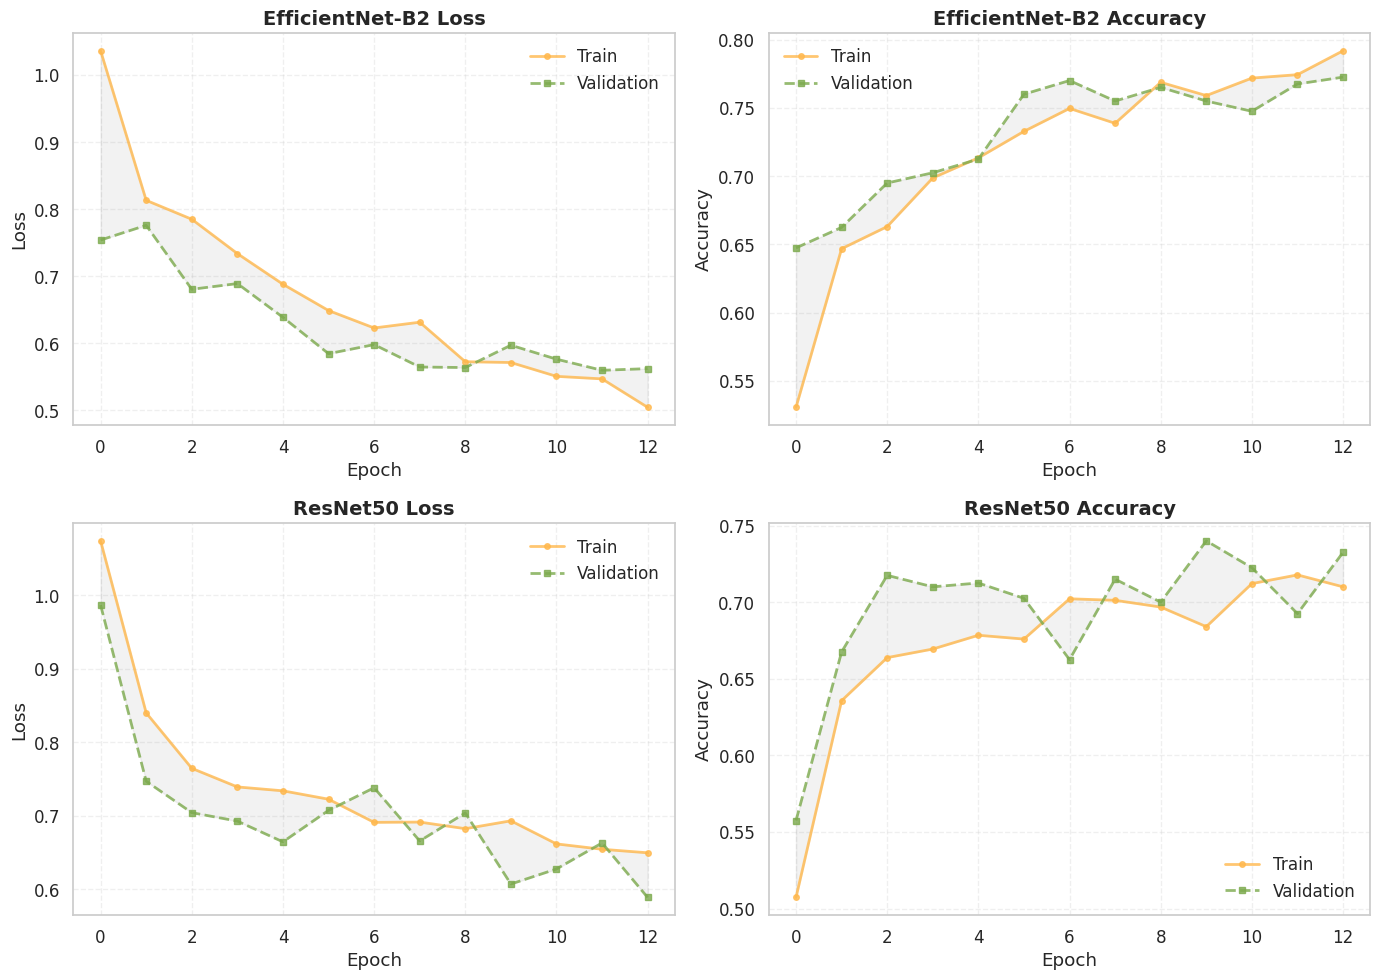

Plot saved as 'models_training_comparison.png'

Final Results:
EfficientNet-B2 - Final Train Acc: 0.7918, Val Acc: 0.7725
ResNet50 - Final Train Acc: 0.7100, Val Acc: 0.7325


In [ ]:
# Set theme
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)

# Set font to sans-serif
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# EfficientNet-B2 training data
efficientnet_history = {
    'train_loss': [1.0362, 0.8132, 0.7850, 0.7338, 0.6881, 0.6489, 0.6229, 0.6315, 0.5726, 0.5714, 0.5508, 0.5470, 0.5046],
    'val_loss': [0.7540, 0.7760, 0.6806, 0.6891, 0.6388, 0.5846, 0.5981, 0.5647, 0.5639, 0.5972, 0.5764, 0.5598, 0.5623],
    'train_acc': [0.5308, 0.6469, 0.6631, 0.6987, 0.7134, 0.7328, 0.7496, 0.7387, 0.7687, 0.7590, 0.7718, 0.7743, 0.7918],
    'val_acc': [0.6475, 0.6625, 0.6950, 0.7025, 0.7125, 0.7600, 0.7700, 0.7550, 0.7650, 0.7550, 0.7475, 0.7675, 0.7725]
}

# ResNet50 training data
resnet_history = {
    'train_loss': [1.0741, 0.8401, 0.7647, 0.7394, 0.7341, 0.7227, 0.6912, 0.6916, 0.6826, 0.6933, 0.6619, 0.6546, 0.6498],
    'val_loss': [0.9867, 0.7471, 0.7044, 0.6929, 0.6647, 0.7075, 0.7383, 0.6659, 0.7040, 0.6073, 0.6278, 0.6632, 0.5891],
    'train_acc': [0.5073, 0.6357, 0.6638, 0.6694, 0.6784, 0.6759, 0.7022, 0.7012, 0.6968, 0.6840, 0.7121, 0.7178, 0.7100],
    'val_acc': [0.5575, 0.6675, 0.7175, 0.7100, 0.7125, 0.7025, 0.6625, 0.7150, 0.7000, 0.7400, 0.7225, 0.6925, 0.7325]
}

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor='white')

# EfficientNet-B2 Loss
axes[0, 0].plot(efficientnet_history['train_loss'], label='Train',
                color='#FFB84D', linewidth=2, marker='o', markersize=4, alpha=0.8)
axes[0, 0].plot(efficientnet_history['val_loss'], label='Validation',
                color='#7CAA4D', linewidth=2, linestyle='--', marker='s', markersize=4, alpha=0.8)
axes[0, 0].fill_between(range(len(efficientnet_history['train_loss'])),
                        efficientnet_history['train_loss'],
                        efficientnet_history['val_loss'],
                        color='gray', alpha=0.1)
axes[0, 0].set_title('EfficientNet-B2 Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(frameon=False)
axes[0, 0].grid(True, linestyle='--', alpha=0.3)

# EfficientNet-B2 Accuracy
axes[0, 1].plot(efficientnet_history['train_acc'], label='Train',
                color='#FFB84D', linewidth=2, marker='o', markersize=4, alpha=0.8)
axes[0, 1].plot(efficientnet_history['val_acc'], label='Validation',
                color='#7CAA4D', linewidth=2, linestyle='--', marker='s', markersize=4, alpha=0.8)
axes[0, 1].fill_between(range(len(efficientnet_history['train_acc'])),
                        efficientnet_history['train_acc'],
                        efficientnet_history['val_acc'],
                        color='gray', alpha=0.1)
axes[0, 1].set_title('EfficientNet-B2 Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend(frameon=False)
axes[0, 1].grid(True, linestyle='--', alpha=0.3)

# ResNet50 Loss
axes[1, 0].plot(resnet_history['train_loss'], label='Train',
                color='#FFB84D', linewidth=2, marker='o', markersize=4, alpha=0.8)
axes[1, 0].plot(resnet_history['val_loss'], label='Validation',
                color='#7CAA4D', linewidth=2, linestyle='--', marker='s', markersize=4, alpha=0.8)
axes[1, 0].fill_between(range(len(resnet_history['train_loss'])),
                        resnet_history['train_loss'],
                        resnet_history['val_loss'],
                        color='gray', alpha=0.1)
axes[1, 0].set_title('ResNet50 Loss', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend(frameon=False)
axes[1, 0].grid(True, linestyle='--', alpha=0.3)

# ResNet50 Accuracy
axes[1, 1].plot(resnet_history['train_acc'], label='Train',
                color='#FFB84D', linewidth=2, marker='o', markersize=4, alpha=0.8)
axes[1, 1].plot(resnet_history['val_acc'], label='Validation',
                color='#7CAA4D', linewidth=2, linestyle='--', marker='s', markersize=4, alpha=0.8)
axes[1, 1].fill_between(range(len(resnet_history['train_acc'])),
                        resnet_history['train_acc'],
                        resnet_history['val_acc'],
                        color='gray', alpha=0.1)
axes[1, 1].set_title('ResNet50 Accuracy', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend(frameon=False)
axes[1, 1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('models_training_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'models_training_comparison.png'")
print("\nFinal Results:")
print(f"EfficientNet-B2 - Final Train Acc: {efficientnet_history['train_acc'][-1]:.4f}, Val Acc: {efficientnet_history['val_acc'][-1]:.4f}")
print(f"ResNet50 - Final Train Acc: {resnet_history['train_acc'][-1]:.4f}, Val Acc: {resnet_history['val_acc'][-1]:.4f}")